<a href="https://colab.research.google.com/github/Morasharvey/CPE-018-CPE31S2/blob/main/Moras_CPE018_MidtermExam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPE018 Midterm Exam (2025-2026)


Student Submission Details:
* Name: Moras, Harvey Jayrell Y.
* Section: CPE31S2
* Schedule: Monday 4:30 PM
* Instructor: Engr. Maria Rizette H. Sayo

---

## Intended Learning Outcomes

By the end of this activity, the student should be able to:
* ILO1: Demonstrate different methods for feature matching and detection learned in class and indepdentently from new sources.
* ILO2: Evaluate the accuracy of different feature matching and detection methods and scrutinize its applicability in solving a given real-life problem.

---

## Tasks

For this examination, you must create a **mood detection** program with an object-oriented programming approach (same as project CAMEO), it must detect mood changes through the use of algorithms/techniques/schemes learned in class, and from external sources.

In this file, you have to include for each section of your solution your completion of the following:

* Part 1: **Face Detection**: Once your face is detected using any algorithm, it must draw an ROI. The color for the ROI is your choice; however, it must detect for all faces in the frame and draw a corresponding ROI.
* Part 2: **Face Recognition**: The detected face must then be recognized, using any of the provided tools in class, the ROIs must indicate whether it is your face or someone it doesn't recognize.
* Part 3: **Mood Detection**: Use three different feature detection and matching techniques to determine three emotion: happy, sad and neutral. Two of the techniques must be learned from class, and 1 must be one you independently learned.

Properly show through your notebook the output for each part of the exam.

---

## Procedure and Outputs

Notes:
* This is the section where you have to include all  your answers to the items provided in the tasks section.
* Tasks 1 and 2 contribute directly to ILO1: Demonstrate different methods for feature matching and detection learned in class and indepdentently from new sources.
* Task 3 contributes directly to ILO2: Evaluate the accuracy of different feature matching and detection methods and scrutinize its applicability in solving a given real-life problem.

### Task 1: Face Detection

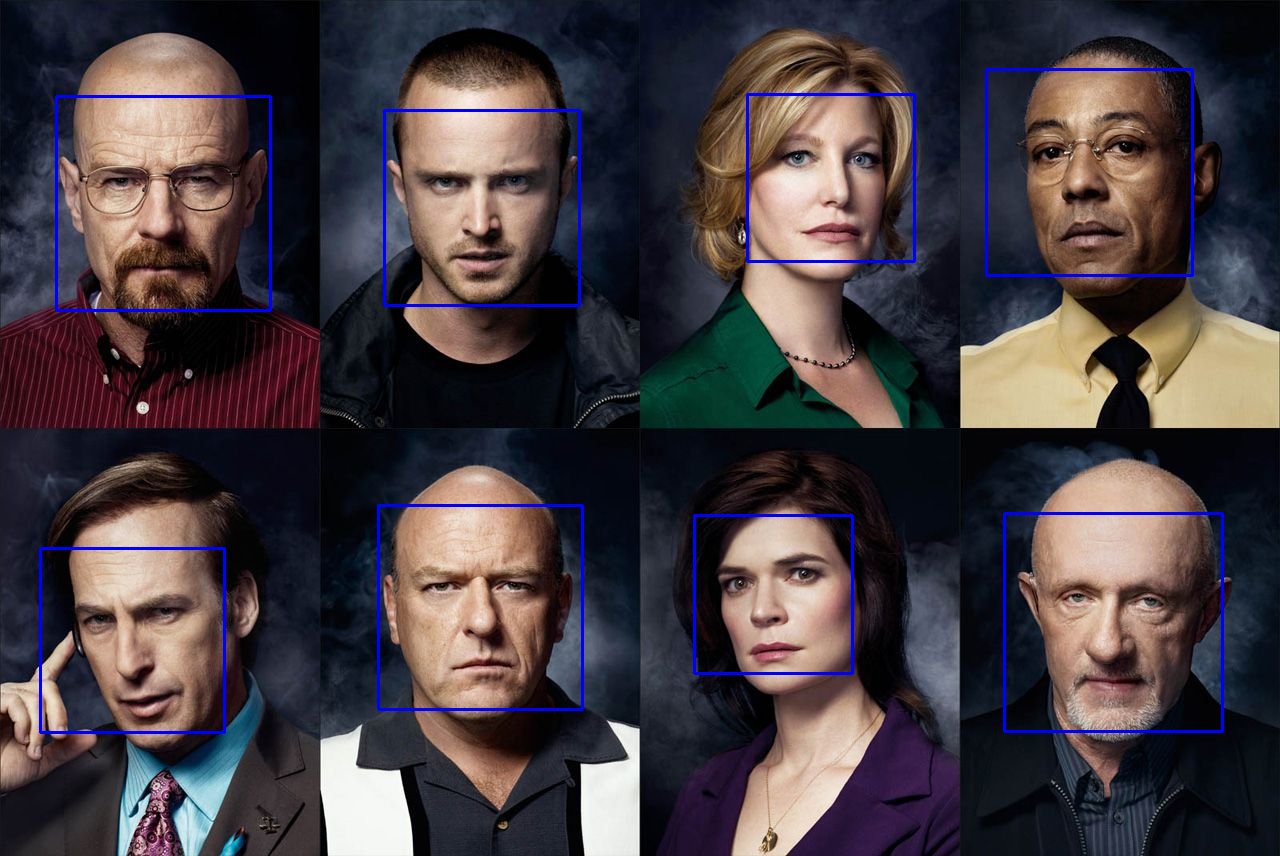

In [10]:
import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/brikinbad.jpg'
HaarPath = '/content/haarcascade_frontalface_default.xml'

def faceDetect(picPath):
  face_cascade = cv2.CascadeClassifier(HaarPath)

  img = cv2.imread(picPath)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.3, 4)

  for (x,y,w,h) in faces:
    img = cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,0), 2)

  cv2_imshow(img)
  cv2.waitKey()

faceDetect(picPath)



### Task 2: Face Recognition

In [12]:
!pip install face_recognition opencv-python



kilala mo na mukha, basta mukha


Saving the_goat_wally.webp to the_goat_wally (1).webp
Known faces encoded: ['the_goat_wally (1)']

Upload test image containing faces to recognize


Saving wally.jpg to wally (1).jpg


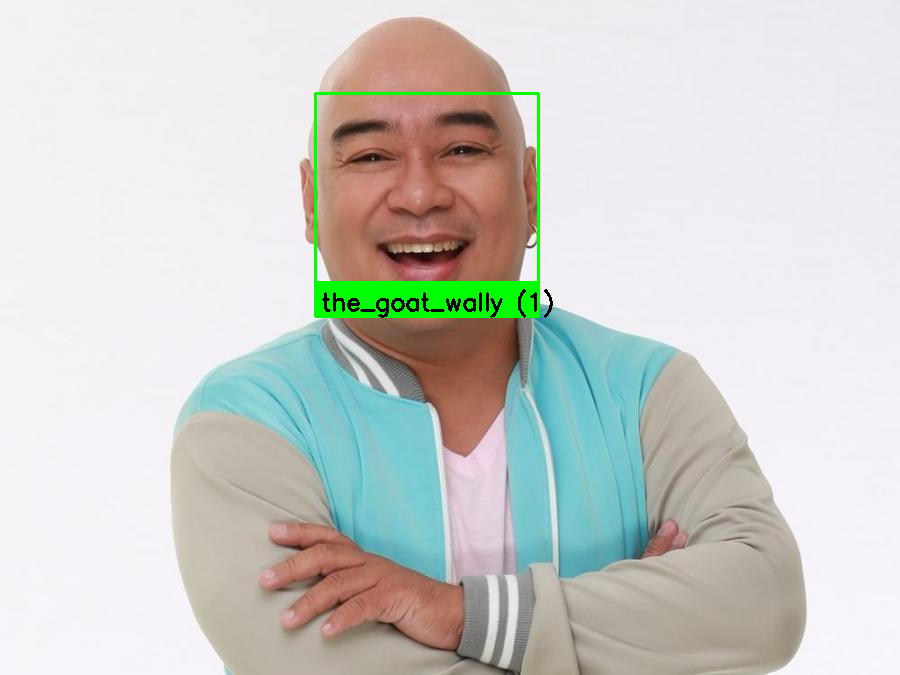

In [16]:
import face_recognition
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

print("kilala mo na mukha, basta mukha")
uploaded = files.upload()

known_face_encodings = []
known_face_names = []

for filename in uploaded.keys():

    image = face_recognition.load_image_file(filename)
    encodings = face_recognition.face_encodings(image)

    if len(encodings) > 0:
        encoding = encodings[0]
        known_face_encodings.append(encoding)

        name = filename.split(".")[0]
        known_face_names.append(name)

print("Known faces encoded:", known_face_names)

print("\nUpload test image containing faces to recognize")
uploaded_test = files.upload()

test_filename = list(uploaded_test.keys())[0]
test_image = face_recognition.load_image_file(test_filename)

face_locations = face_recognition.face_locations(test_image)
face_encodings = face_recognition.face_encodings(test_image, face_locations)
image = cv2.imread(test_filename)
for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

    matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
    name = "Unknown"

    if len(known_face_encodings) > 0:
        face_distances = face_recognition.face_distance(known_face_encodings, face_encoding)
        best_match_index = np.argmin(face_distances)

        if matches[best_match_index]:
            name = known_face_names[best_match_index]
    cv2.rectangle(image, (left, top), (right, bottom), (0,255,0), 2)
    cv2.rectangle(image, (left, bottom-35), (right, bottom), (0,255,0), cv2.FILLED)
    cv2.putText(image, name, (left+6, bottom-6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0), 2)
cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Task 3: Mood Detection

## Analysis

For the three different techniques you used in face detection, provide an in-depth analysis.

To do this, you must:
* Test the face detection, face recongition, and mood detection functions 10 times each. Only the mood detection will have components for 10 tests for each different technique used.
* Create a table containing the 10 tests (like shown below) for each task.
* Analyze each output by identifying the accuracy and providing your observations.

In [ ]:
# Import the module for tabulating the data
from tabulate import tabulate

# Create a list for content of the table
test_results = [
    ["1", "Happy", "Sad", 0],
    ["2", "Happy", "Neutral", 0],
    ["3", "Happy", "Happy", 1]
]

# Create a list for the headers of your table
header = ["Test #", "Expected", "Actual", "Score"]

# display table
print("Task 3A: Mood Detection using XYZ Algorithm")
print(tabulate(test_results, headers=header, tablefmt="grid"))

# Calculate for the accuracy
total = 0
for i in test_results:
    total += i[3]
print("Accuracy: ", round(total/len(test_results)*100,2))

Task 3A: Mood Detection using XYZ Algorithm
+----------+------------+----------+---------+
|   Test # | Expected   | Actual   |   Score |
+==========+============+==========+=========+
|        1 | Happy      | Sad      |       0 |
+----------+------------+----------+---------+
|        2 | Happy      | Neutral  |       0 |
+----------+------------+----------+---------+
|        3 | Happy      | Happy    |       1 |
+----------+------------+----------+---------+
Accuracy:  33.33


---

## Summary and Lessons Learned

This section must be answered concisely. Do not engage in unmeaningful writing for the summary and lessons learned. Provide your brief reflection only.

---

in doing this activity i find it hard to do the task 3 which is the different mood detection so i am unable to perform and test it. but i learned a lot from this midterm exam in terms of doing the code for the face detection and face recognition.

**Proprietary Clause**

Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated or reduced to any electronic medium or machine-readable form, in whole or in part, without prior consent of T.I.P.

Prepared by Engr. RMR